In [1]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import sys
import re
from tqdm import tqdm
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm

# import some tools from the wider directory
sys.path.insert(0, os.path.abspath('..'))   # adds fastersimulation/ to the path
import utilities
path = "../results/rings_sweep/"
out_path = os.path.join(path, "combined_sweep.h5")
collate=False

In [2]:
if collate:
    def _parse_folder(folder_name):
        """
        rings1_focal5000.0
        """
        m = re.search(
            r"^rings([^_]+)_focal([^_]+)$",
            folder_name
        )
        if m:
            try:
                return (
                    float(m.group(1)),  # rings
                    float(m.group(2)),  # focal
                )
            except ValueError:
                pass
        return -1.0, -1.0

    # Discover all simulation folders
    sweep_dirs = [
        d for d in os.listdir(path)
        if os.path.isdir(os.path.join(path, d)) and d.startswith("rings")
    ]

    # Sort hierarchically by calkp, calkd, obskp, obskd, ki
    sweep_dirs.sort(key=lambda d: _parse_folder(d))

    out_path = os.path.join(path, "combined_sweep.h5")
    missing = []

    print(f"Collating {len(sweep_dirs)} folders into {out_path}...")

    with h5py.File(out_path, "w") as out_f:
        for folder in tqdm(sweep_dirs):
            rings, focal = _parse_folder(folder)

            if rings < 1:
                print(f"  [SKIP] {folder} — could not parse parameters")
                continue

            h5_path = os.path.join(path, folder, "mirror_states.h5")
            if not os.path.isfile(h5_path):
                print(f"  [SKIP] rings={rings}, focal={focal} — mirror_states.h5 not found")
                missing.append(folder)
                continue

            group_name = f"rings={rings}, focal={focal}"

            with h5py.File(h5_path, "r") as src_f:
                dst_grp = out_f.create_group(group_name)
                for key in src_f.keys():
                    src_f.copy(key, dst_grp, name=key)

    print(f"\nSaved combined file → {out_path}")
    if missing:
        print(f"WARNING: {len(missing)} folders had no mirror_states.h5 file!")


Collating 16 folders into ../results/rings_sweep/combined_sweep.h5...


  0%|          | 0/16 [00:00<?, ?it/s]

  [SKIP] rings0_focal5000.0 — could not parse parameters


100%|██████████| 16/16 [05:04<00:00, 19.05s/it]



Saved combined file → ../results/rings_sweep/combined_sweep.h5


In [4]:
def _h5_tree(item, indent=0, max_seg=2, first_only=False):
    """Recursively print an HDF5 tree, optionally only the first root group."""
    prefix = "  " * indent

    def _parse_root_group(name):
        if not name.startswith("rings"):
            return (-1.0, -1.0)
        parts = name.split("_")
        try:
            return (
                float(parts[1]),
                float(parts[3]),
            )
        except (IndexError, ValueError):
            return (-1.0, -1.0)

    def _segment_index(name):
        try:
            return int(name.split("_")[1])
        except (IndexError, ValueError):
            return -1

    if isinstance(item, h5py.File):
        print(f"{prefix}/ (attrs: {dict(item.attrs)})")

        children = sorted(item.keys(), key=_parse_root_group)

        if first_only and children:
            _h5_tree(item[children[0]], indent + 1, max_seg, first_only)
        else:
            for k in children:
                _h5_tree(item[k], indent + 1, max_seg, first_only)

    elif isinstance(item, h5py.Group):
        name = item.name.split("/")[-1]
        children = list(item.keys())

        seg_keys = sorted(
            [k for k in children if k.startswith("segment_")],
            key=_segment_index
        )
        other_keys = sorted(
            [k for k in children if not k.startswith("segment_")]
        )

        print(f"{prefix}┣ {name}/")

        for k in other_keys:
            _h5_tree(item[k], indent + 1, max_seg, first_only)

        for k in seg_keys[:max_seg]:
            _h5_tree(item[k], indent + 1, max_seg, first_only)

        if len(seg_keys) > max_seg:
            print(f"{'  ' * (indent + 1)}┆ ... ({len(seg_keys) - max_seg} more segment_ groups)")

    elif isinstance(item, h5py.Dataset):
        name = item.name.split("/")[-1]
        print(f"{prefix}┃  {name:30s}  {str(item.shape):20s}  {item.dtype}")


# ── Execute ──
with h5py.File(out_path, "r") as f:
    _h5_tree(f, max_seg=1, first_only=True)

/ (attrs: {})
  ┣ rings=1.0, focal=5000.0/
    ┣ config/
      ┃  star_vector                     (3,)                  float64
    ┃  dv                              (513920,)             float64
    ┃  dv_xyz                          (513920, 3)           float64
    ┃  mirror_time                     (90000,)              float64
    ┃  phase                           (513920,)             object
    ┃  r_app_eci                       (513920, 3)           float64
    ┃  r_det_eci                       (513920, 3)           float64
    ┃  rel_pos_B                       (90000, 3)            float64
    ┃  rel_sigma_B                     (513920, 3)           float64
    ┃  sigma_app_star                  (513920, 3)           float64
    ┃  sigma_det_star                  (513920, 3)           float64
    ┃  time                            (513920,)             float64
    ┣ segment_0/
      ┃  desired_mirror_actuation        (90000, 6)            float64
      ┃  mirror_actuation 

In [5]:
import h5py
import re
import numpy as np
from tqdm import tqdm

def _parse_grp(x):
    """
    Parse group names like: rings=1.0, focal=5000.0/
    """
    m = re.search(
        r"^rings=([^,]+),\s*focal=([^,]+)$",
        x
    )
    if m:
        try:
            return (
                float(m.group(1)),  # rings
                float(m.group(2)),  # focal
            )
        except ValueError:
            pass
    return (-1.0, -1.0)

def _get_ds(run_grp, name):
    """Helper to check both root and config sub-group for a dataset."""
    if "config" in run_grp and name in run_grp["config"]:
        return run_grp["config"][name][:]
    if name in run_grp:
        return run_grp[name][:]
    raise KeyError(f"Dataset '{name}' not found in '{run_grp.name}' or its config/group")

with h5py.File(out_path, "r") as src_f:
    # 1. Identify and sort simulation runs
    group_keys = sorted(
        [k for k in src_f.keys() if k.startswith("rings=")],
        key=_parse_grp
    )

    num_runs = len(group_keys)
    print(f"Total number of simulation runs = {num_runs}")

    if num_runs == 0:
        raise ValueError("No simulation groups found in the HDF5 file.")

    # 2. Initialize storage containers
    # Global/Run-level data
    phase, full_times, eng_times = [], [], []
    rings_vals, focal_vals = [], []
    r_app_eci, r_det_eci, rel_pos_B = [], [], []
    dv, dv_xyz = [], []

    # Segment-level data (Lists of lists: [run][segment])
    all_mirror_actuation = []
    all_desired_mirror_actuation = []
    all_point_on_det_plane = []

    # 3. Main processing loop
    for group in tqdm(group_keys, desc="Processing Simulations"):
        run_grp = src_f[group]
        rings, focal = _parse_grp(group)

        # Store parameters
        rings_vals.append(rings)
        focal_vals.append(focal)

        # Store run-level arrays
        phase_arr = _get_ds(run_grp, "phase")
        phase.append(np.array(phase_arr, dtype=str))
        full_times.append(_get_ds(run_grp, "time"))
        eng_times.append(_get_ds(run_grp, "mirror_time"))
        r_app_eci.append(_get_ds(run_grp, "r_app_eci"))
        r_det_eci.append(_get_ds(run_grp, "r_det_eci"))
        rel_pos_B.append(_get_ds(run_grp, "rel_pos_B"))

        # Handle dv and dv_xyz logic
        if "config" in run_grp and "dv" in run_grp["config"]:
            dv.append(run_grp["config"]["dv"][:])
        elif "dv" in run_grp:
            dv.append(run_grp["dv"][:])

        if "config" in run_grp and "dv_xyz" in run_grp["config"]:
            dv_xyz.append(run_grp["config"]["dv_xyz"][:])
        elif "dv_xyz" in run_grp:
            dv_xyz.append(run_grp["dv_xyz"][:])

        # 4. Handle Nested Segments (segment_0, segment_1, etc.)
        # Sort keys to ensure segment sequence is preserved
        segment_keys = sorted([k for k in run_grp.keys() if k.startswith("segment_")])
        
        run_mirror = []
        run_desired_mirror = []
        run_det_plane = []

        for seg_key in segment_keys:
            seg_grp = run_grp[seg_key]
            run_mirror.append(seg_grp["mirror_actuation"][:])
            run_desired_mirror.append(seg_grp["desired_mirror_actuation"][:])
            run_det_plane.append(seg_grp["point_on_det_plane"][:])

        all_mirror_actuation.append(run_mirror)
        all_desired_mirror_actuation.append(run_desired_mirror)
        all_point_on_det_plane.append(run_det_plane)

print("\nData successfully loaded!")
print(f"Loaded {len(all_mirror_actuation)} runs, each containing {len(all_mirror_actuation[0])} segments.")

Total number of simulation runs = 15


Processing Simulations: 100%|██████████| 15/15 [06:58<00:00, 27.91s/it]


Data successfully loaded!
Loaded 15 runs, each containing 7 segments.


# EXTRACT SEG POSITIONS

In [6]:
import h5py
import re
from tqdm import tqdm

def _parse_grp(x):
    m = re.search(r"^rings=([^,]+),\s*focal=([^,]+)$", x)
    if m:
        return float(m.group(1)), float(m.group(2))
    return (-1.0, -1.0)

rings_to_centers = {}

with h5py.File(out_path, "r") as src_f:
    group_keys = sorted(
        [k for k in src_f.keys() if k.startswith("rings=")],
        key=_parse_grp
    )

    for group in tqdm(group_keys, desc="Extracting hex centers"):
        run_grp = src_f[group]
        rings, _ = _parse_grp(group)
        rings = int(rings)

        segment_keys = sorted(
            [k for k in run_grp.keys() if k.startswith("segment_")],
            key=lambda s: int(s.split("_")[1])
        )

        centers = []

        for seg_key in segment_keys:
            seg_grp = run_grp[seg_key]

            # Take final timestep
            final_pos = seg_grp["position"][-1]

            # Extract x, y (first two components)
            x, y = final_pos[0], final_pos[1]
            centers.append((x, y))

        rings_to_centers[rings] = centers

print("Done.")
print(f"Available rings: {list(rings_to_centers.keys())}")
#print(f"Example entry:\n{list(rings_to_centers.items())[0]}")

Extracting hex centers: 100%|██████████| 15/15 [00:01<00:00,  9.38it/s]

Done.
Available rings: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


100%|██████████| 1/1 [00:03<00:00,  3.38s/it]


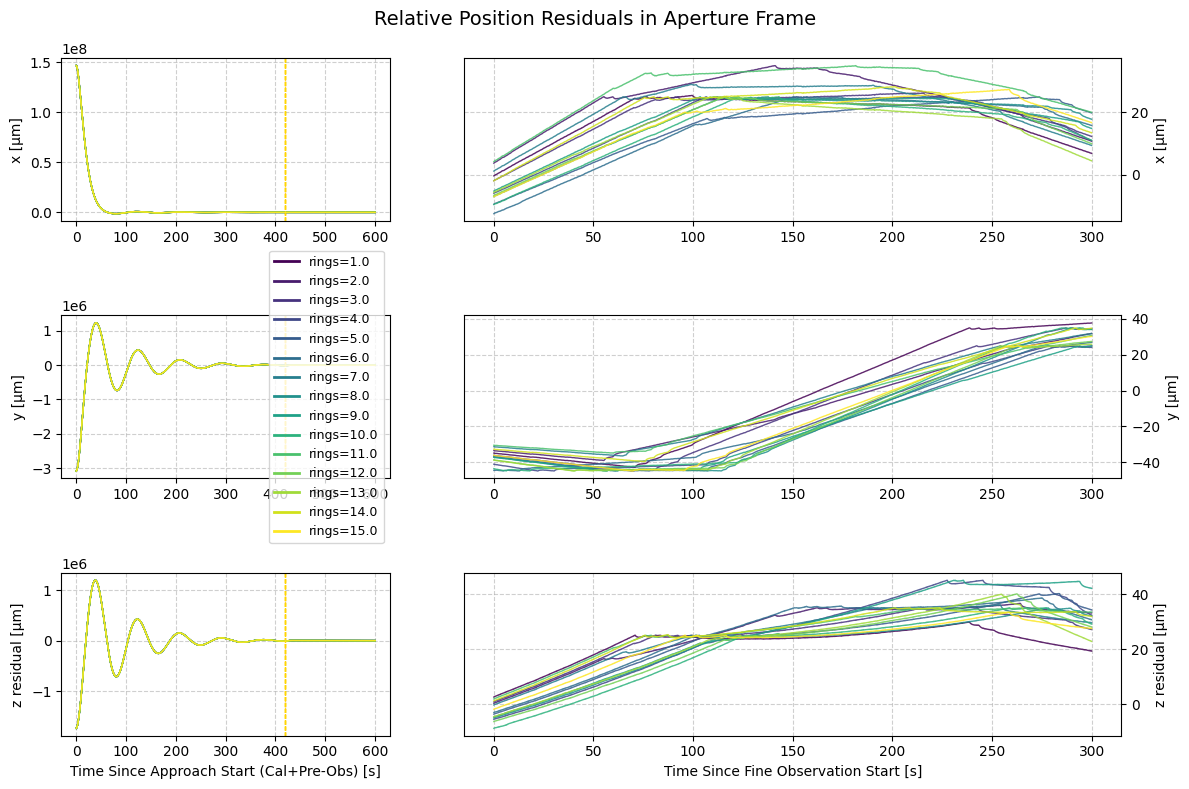

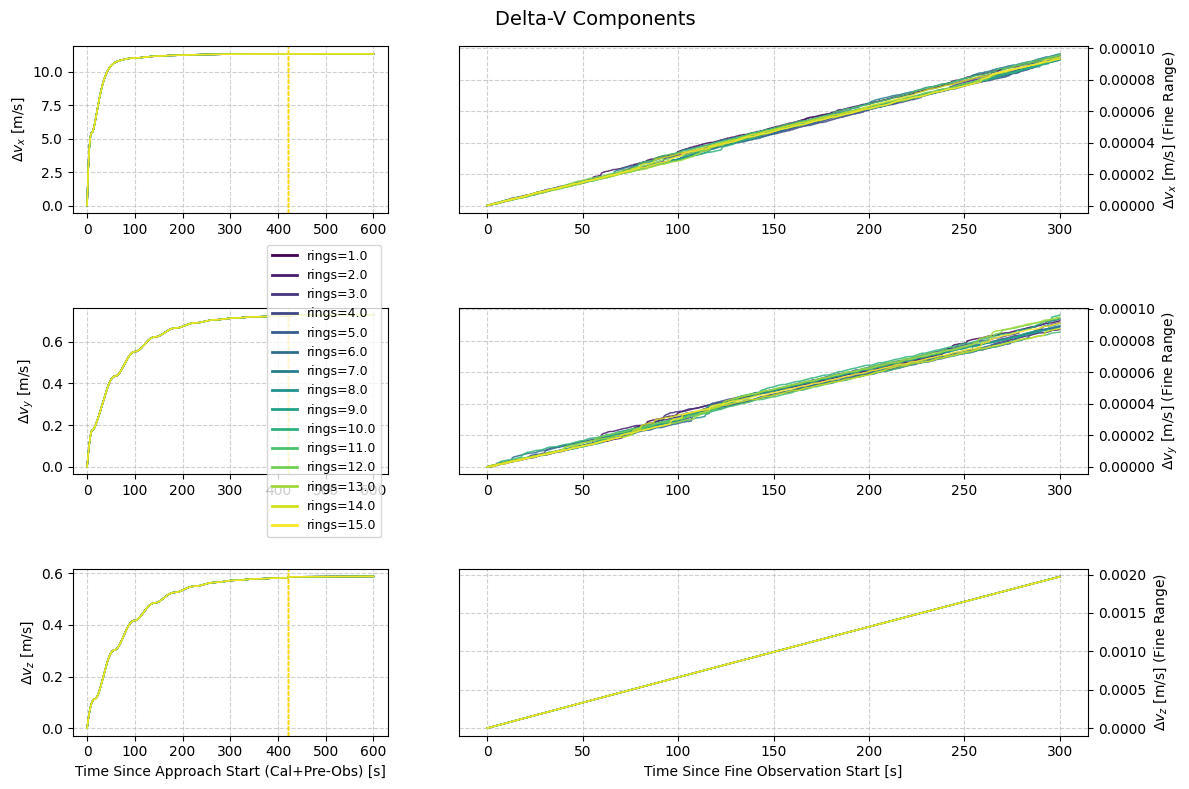

In [8]:
coord_letter = ["x", "y", "z"]
alpha_lines = 0.7
current_focal = 5000.0

# --- Color map: one color per unique rings value ---
unique_rings = sorted(set(rings_vals))
cmap = plt.get_cmap("viridis", len(unique_rings))
ring_to_color = {r: cmap(i) for i, r in enumerate(unique_rings)}

# --- Output directories ---
resid_out_dir = "../analysis_scripts/rings_figs/"
dv_out_dir = "../analysis_scripts/rings_figs/"
os.makedirs(resid_out_dir, exist_ok=True)
os.makedirs(dv_out_dir, exist_ok=True)

# Optional legends
legend_elements = [
    Line2D([0], [0], color=ring_to_color[r], lw=2, label=f"rings={r}")
    for r in unique_rings
]

# Loop once, but keep structure similar to your original code
for _ in tqdm([0]):

    # ----------------------------
    # Relative position residuals
    # ----------------------------
    rel_pos_fig = plt.figure(figsize=(12, 8))
    gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], figure=rel_pos_fig)
    rel_pos_fig.suptitle("Relative Position Residuals in Aperture Frame", fontsize=14)

    rel_pos_ax = []
    for row in range(3):
        ax_approach = rel_pos_fig.add_subplot(gs[row, 0])
        ax_fine = rel_pos_fig.add_subplot(gs[row, 1])
        ax_fine.yaxis.tick_right()
        ax_fine.yaxis.set_label_position("right")
        rel_pos_ax.append((ax_approach, ax_fine))

    rel_pos_ax[2][0].set_xlabel("Time Since Approach Start (Cal+Pre-Obs) [s]")
    rel_pos_ax[2][1].set_xlabel("Time Since Fine Observation Start [s]")

    for coord in range(3):
        label = coord_letter[coord]
        if coord == 2:
            label = "z residual"
        rel_pos_ax[coord][0].set_ylabel(f"{label} [µm]")
        rel_pos_ax[coord][1].set_ylabel(f"{label} [µm]")
        rel_pos_ax[coord][0].grid(True, linestyle="--", alpha=0.6)
        rel_pos_ax[coord][1].grid(True, linestyle="--", alpha=0.6)

    for i in range(len(phase)):
        t_full = np.asarray(full_times[i])
        t_eng = np.asarray(eng_times[i])
        rel = np.asarray(rel_pos_B[i])
        phase_i = np.array(phase[i], dtype=str)

        cal_idx = np.where(phase_i == "Calibration")[0]
        pre_obs_idx = np.where(phase_i == "Pre-Observation")[0]
        fine_idx = np.where(phase_i == "Fine Observation")[0]

        approach_indices = np.concatenate([cal_idx, pre_obs_idx]) if (len(cal_idx) or len(pre_obs_idx)) else np.array([])

        if len(approach_indices) > 0:
            t_approach_start = t_full[approach_indices[0]]
            t_approach_end = t_full[approach_indices[-1]]
            approach_mask = (t_eng >= t_approach_start) & (t_eng <= t_approach_end)
        else:
            approach_mask = np.zeros_like(t_eng, dtype=bool)

        if len(fine_idx) > 0:
            t_fine_start = t_full[fine_idx[0]]
            t_fine_end = t_full[fine_idx[-1]]
            fine_mask = (t_eng >= t_fine_start) & (t_eng <= t_fine_end)
        else:
            fine_mask = np.zeros_like(t_eng, dtype=bool)

        app_t = t_eng[approach_mask]
        app_rel = rel[approach_mask]
        fine_t = t_eng[fine_mask]
        fine_rel = rel[fine_mask]

        if len(app_t) > 0:
            app_t = app_t - app_t[0]
        if len(fine_t) > 0:
            fine_t = fine_t - fine_t[0]

        if len(pre_obs_idx) > 0 and len(approach_indices) > 0:
            pre_obs_t_start = t_full[pre_obs_idx[0]] - t_full[approach_indices[0]]
            for coord in range(3):
                rel_pos_ax[coord][0].axvline(
                    pre_obs_t_start,
                    color="gold",
                    lw=0.8,
                    ls="--",
                    alpha=0.7,
                    label="Pre-Obs start" if i == 0 else None,
                )

        one_ring_val = rings_vals[i]
        color = ring_to_color[one_ring_val]
        lw = 1.0
        alpha = 0.85
        zorder = 2

        for coord in range(3):
            scale = 1e6  # m -> µm

            if coord == 2:
                app_vals = (app_rel[:, coord] - current_focal) * scale if len(app_rel) > 0 else np.array([])
                fine_vals = (fine_rel[:, coord] - current_focal) * scale if len(fine_rel) > 0 else np.array([])
            else:
                app_vals = app_rel[:, coord] * scale if len(app_rel) > 0 else np.array([])
                fine_vals = fine_rel[:, coord] * scale if len(fine_rel) > 0 else np.array([])

            if len(app_t) > 0 and len(app_vals) > 0:
                rel_pos_ax[coord][0].plot(app_t, app_vals, lw=lw, color=color, alpha=alpha, zorder=zorder)

            if len(fine_t) > 0 and len(fine_vals) > 0:
                rel_pos_ax[coord][1].plot(fine_t, fine_vals, lw=lw, color=color, alpha=alpha, zorder=zorder)

    rel_pos_ax[1][0].legend(handles=legend_elements,loc="right", fontsize=9)
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.15)
    plt.savefig(os.path.join(resid_out_dir, "residuals_by_rings.png"), dpi=300, bbox_inches="tight")
    #plt.close(rel_pos_fig)

    # ----------------------------
    # Delta-V components
    # ----------------------------
    dv_fig = plt.figure(figsize=(12, 8))
    gs = gridspec.GridSpec(3, 2, width_ratios=[1, 2], figure=dv_fig)
    dv_fig.suptitle("Delta-V Components", fontsize=14)

    dv_ax = []
    for row in range(3):
        ax_approach = dv_fig.add_subplot(gs[row, 0])
        ax_fine = dv_fig.add_subplot(gs[row, 1])
        ax_fine.yaxis.tick_right()
        ax_fine.yaxis.set_label_position("right")
        dv_ax.append((ax_approach, ax_fine))

    dv_ax[2][0].set_xlabel("Time Since Approach Start (Cal+Pre-Obs) [s]")
    dv_ax[2][1].set_xlabel("Time Since Fine Observation Start [s]")

    for coord in range(3):
        label = coord_letter[coord]
        dv_ax[coord][0].set_ylabel(f"$\\Delta v_{label}$ [m/s]")
        dv_ax[coord][1].set_ylabel(f"$\\Delta v_{label}$ [m/s] (Fine Range)")
        dv_ax[coord][0].grid(True, linestyle="--", alpha=0.6)
        dv_ax[coord][1].grid(True, linestyle="--", alpha=0.6)

    for i in range(len(phase)):
        t_full = np.asarray(full_times[i])
        dv_run = np.asarray(dv_xyz[i])
        phase_i = np.array(phase[i], dtype=str)

        cal_idx = np.where(phase_i == "Calibration")[0]
        pre_obs_idx = np.where(phase_i == "Pre-Observation")[0]
        fine_idx = np.where(phase_i == "Fine Observation")[0]

        approach_indices = np.concatenate([cal_idx, pre_obs_idx]) if (len(cal_idx) or len(pre_obs_idx)) else np.array([])

        if len(approach_indices) > 0:
            approach_mask = (t_full >= t_full[approach_indices[0]]) & (t_full <= t_full[approach_indices[-1]])
        else:
            approach_mask = np.zeros_like(t_full, dtype=bool)

        if len(fine_idx) > 0:
            fine_mask = (t_full >= t_full[fine_idx[0]]) & (t_full <= t_full[fine_idx[-1]])
        else:
            fine_mask = np.zeros_like(t_full, dtype=bool)

        app_t = t_full[approach_mask]
        app_dv = dv_run[approach_mask]
        fine_t = t_full[fine_mask]
        fine_dv = dv_run[fine_mask]

        if len(app_t) > 0:
            app_t = app_t - app_t[0]
        if len(fine_t) > 0:
            fine_t = fine_t - fine_t[0]

        if len(pre_obs_idx) > 0 and len(approach_indices) > 0:
            pre_obs_t_start = t_full[pre_obs_idx[0]] - t_full[approach_indices[0]]
            for coord in range(3):
                dv_ax[coord][0].axvline(
                    pre_obs_t_start,
                    color="gold",
                    lw=0.8,
                    ls="--",
                    alpha=0.7,
                    label="Pre-Obs start" if i == 0 else None,
                )

        one_ring_val = rings_vals[i]
        color = ring_to_color[one_ring_val]
        lw = 1.0
        alpha = 0.85
        zorder = 2

        for coord in range(3):
            if len(app_t) > 0:
                dv_ax[coord][0].plot(
                    app_t,
                    app_dv[:, coord],
                    lw=lw,
                    color=color,
                    alpha=alpha,
                    zorder=zorder,
                )

            if len(fine_t) > 0 and len(app_dv) > 0:
                dv_ax[coord][1].plot(
                    fine_t,
                    fine_dv[:, coord] - app_dv[-1, coord],
                    lw=lw,
                    color=color,
                    alpha=alpha,
                    zorder=zorder,
                )

    dv_ax[1][0].legend(handles=legend_elements,loc="right", fontsize=9)
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.15)
    plt.savefig(os.path.join(dv_out_dir, "deltav_by_rings.png"), dpi=300, bbox_inches="tight")
    #plt.close(dv_fig)

# BUILDING THE PD DATA FRAMES

In [9]:
import numpy as np
import pandas as pd


objs = {
    "phase": phase,
    "full_times": full_times,
    "eng_times": eng_times,
    "rel_pos_B": rel_pos_B,
    "dv": dv,
    "rings_vals": rings_vals,
    "focal_vals": focal_vals,
}

for name, obj in objs.items():
    try:
        print(name, type(obj), len(obj))
    except Exception as e:
        print(name, type(obj), "no len:", e)

rows = []

# Diagnosticsx
skip_no_fine = 0
skip_no_mask = 0
skip_empty = 0
appended = 0

# Assumes these already exist:
# phase, full_times, eng_times, rel_pos_B, dv, ring_vals, focal_vals, current_focal

for idx, (ph_i, t_full_i, t_eng_i, rel_i, dv_i, ring_i, focal_i) in enumerate(
    zip(phase, full_times, eng_times, rel_pos_B, dv, rings_vals, focal_vals)
):
    phase_i = np.char.strip(np.asarray(ph_i, dtype=str))
    t_full = np.asarray(t_full_i)
    t_eng = np.asarray(t_eng_i)
    rel = np.asarray(rel_i)
    dv_i = np.asarray(dv_i)

    # Find Fine Observation segment in the full-rate phase array
    fine_idx = np.where(phase_i == "Fine Observation")[0]
    if len(fine_idx) == 0:
        skip_no_fine += 1
        continue

    t_fine_start = t_full[fine_idx[0]]
    t_fine_end = t_full[fine_idx[-1]]

    # Mask engineering-rate relative position data
    fine_mask_eng = (t_eng >= t_fine_start) & (t_eng <= t_fine_end)

    # Mask full-rate delta-v data
    fine_mask_full = (t_full >= t_fine_start) & (t_full <= t_fine_end)

    if not np.any(fine_mask_eng) or not np.any(fine_mask_full):
        skip_no_mask += 1
        continue

    fine_rel = rel[fine_mask_eng]
    dv_fine_array = dv_i[fine_mask_full]

    if fine_rel.size == 0 or dv_fine_array.size == 0:
        skip_empty += 1
        continue

    rms_x = np.sqrt(np.mean(fine_rel[:, 0] ** 2))
    rms_y = np.sqrt(np.mean(fine_rel[:, 1] ** 2))
    rms_z = np.sqrt(np.mean((fine_rel[:, 2] - current_focal) ** 2))

    rows.append({
        "rings": ring_i,
        "focal": focal_i,
        "rms_x": rms_x * 1e6,
        "rms_y": rms_y * 1e6,
        "rms_z": rms_z * 1e6,
        "dv_cal": dv_fine_array[0],
        "dv_fine": dv_fine_array[-1] - dv_fine_array[0],
    })
    appended += 1

summary_df = pd.DataFrame(rows)

print("appended:", appended)
print("skip_no_fine:", skip_no_fine)
print("skip_no_mask:", skip_no_mask)
print("skip_empty:", skip_empty)
print("summary_df columns:", summary_df.columns.tolist())
print(summary_df.head())

if summary_df.empty:
    raise ValueError("No rows were collected. Check the phase labels and time alignment.")

def create_sorted_pivot(df, value_col):
    if value_col not in df.columns:
        raise KeyError(f"Missing column: {value_col}. Available columns: {df.columns.tolist()}")
    return (
        df.pivot_table(
            index="rings",
            columns="focal",
            values=value_col,
            aggfunc="mean",
        )
        .sort_index()
        .sort_index(axis=1)
    )

rms_x_table = create_sorted_pivot(summary_df, "rms_x")
rms_y_table = create_sorted_pivot(summary_df, "rms_y")
rms_z_table = create_sorted_pivot(summary_df, "rms_z")
dv_cal_table = create_sorted_pivot(summary_df, "dv_cal")
dv_fine_table = create_sorted_pivot(summary_df, "dv_fine")

rms_rho_table = np.sqrt((rms_x_table ** 2) + (rms_y_table ** 2))

print("\n--- RMS Results (scaled by 1e6) ---")
print("RMS X residual table:")
print(rms_x_table)

print("\nRMS Y residual table:")
print(rms_y_table)

print("\nRMS RHO residual table:")
print(rms_rho_table)

print("\nRMS Z residual table:")
print(rms_z_table)

print("\n--- Delta-V CAL Table ---")
print(dv_cal_table)

print("\n--- Delta-V FINE Table ---")
print(dv_fine_table)

print(f"\nTable Dimensions: {rms_x_table.shape}")
print(f"Unique focal values: {len(rms_x_table.columns)}")
print(f"Unique rings values: {len(rms_x_table.index)}")

phase <class 'list'> 15
full_times <class 'list'> 15
eng_times <class 'list'> 15
rel_pos_B <class 'list'> 15
dv <class 'list'> 15
rings_vals <class 'list'> 15
focal_vals <class 'list'> 15
appended: 15
skip_no_fine: 0
skip_no_mask: 0
skip_empty: 0
summary_df columns: ['rings', 'focal', 'rms_x', 'rms_y', 'rms_z', 'dv_cal', 'dv_fine']
   rings   focal      rms_x      rms_y      rms_z     dv_cal   dv_fine
0    1.0  5000.0  19.877537  30.259477  22.949011  11.492938  0.002091
1    2.0  5000.0  25.576532  24.823360  28.422240  11.492941  0.002083
2    3.0  5000.0  21.162204  29.909137  26.628660  11.492938  0.002086
3    4.0  5000.0  19.917491  30.565879  29.999348  11.492939  0.002091
4    5.0  5000.0  18.245609  31.139668  26.327425  11.492940  0.002086

--- RMS Results (scaled by 1e6) ---
RMS X residual table:
focal     5000.0
rings           
1.0    19.877537
2.0    25.576532
3.0    21.162204
4.0    19.917491
5.0    18.245609
6.0    18.725582
7.0    23.031106
8.0    19.921026
9.0    20.1

# MAPPING THE POINTING RMS PER DIRECTION

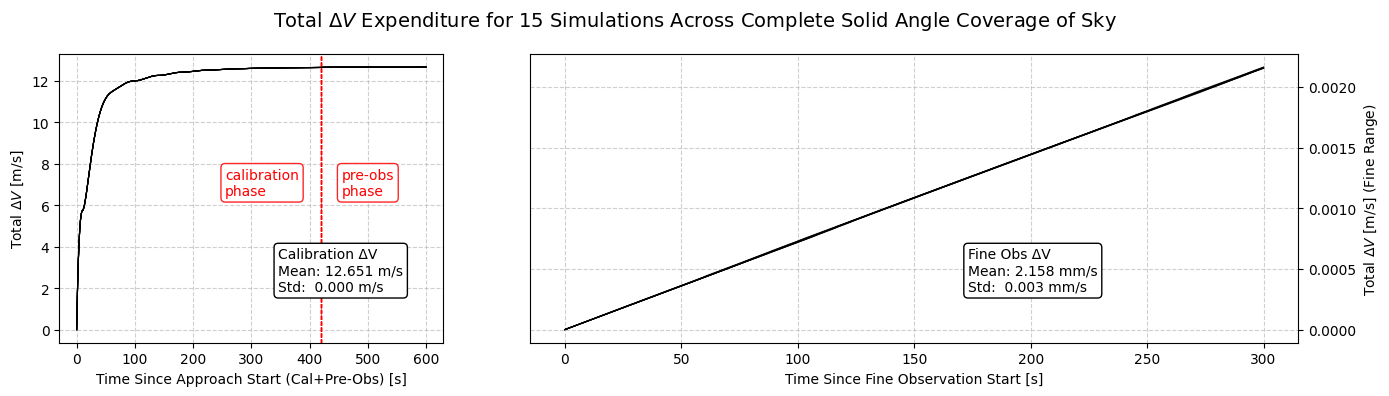

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

alpha_lines = 0.5

dv_fig = plt.figure(figsize=(14, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 2], figure=dv_fig)
dv_fig.suptitle(rf"Total $\Delta V$ Expenditure for {num_runs} Simulations Across Complete Solid Angle Coverage of Sky", fontsize=14)

ax_app  = dv_fig.add_subplot(gs[0, 0])
ax_fine = dv_fig.add_subplot(gs[0, 1])

ax_fine.yaxis.tick_right()
ax_fine.yaxis.set_label_position("right")

ax_app.set_ylabel(r"Total $\Delta V$ [m/s]")
ax_fine.set_ylabel(r"Total $\Delta V$ [m/s] (Fine Range)")

ax_app.set_xlabel("Time Since Approach Start (Cal+Pre-Obs) [s]")
ax_fine.set_xlabel("Time Since Fine Observation Start [s]")

ax_app.grid(True, linestyle="--", alpha=0.6)
ax_fine.grid(True, linestyle="--", alpha=0.6)

# Collect final values for statistics
app_final_vals = []
fine_final_vals = []

for i in range(len(phase)):
    t_full = np.asarray(full_times[i])
    dv_run = np.asarray(dv_xyz[i])  # shape: (N, 3)
    phase_i = np.array(phase[i], dtype=str)

    cal_idx     = np.where(phase_i == "Calibration")[0]
    pre_obs_idx = np.where(phase_i == "Pre-Observation")[0]
    fine_idx    = np.where(phase_i == "Fine Observation")[0]

    approach_indices = np.concatenate([cal_idx, pre_obs_idx]) if (len(cal_idx) + len(pre_obs_idx)) > 0 else np.array([], dtype=int)

    if len(approach_indices) > 0:
        approach_mask = (t_full >= t_full[approach_indices[0]]) & (t_full <= t_full[approach_indices[-1]])
    else:
        approach_mask = np.zeros_like(t_full, dtype=bool)

    if len(fine_idx) > 0:
        fine_mask = (t_full >= t_full[fine_idx[0]]) & (t_full <= t_full[fine_idx[-1]])
    else:
        fine_mask = np.zeros_like(t_full, dtype=bool)

    app_t  = t_full[approach_mask]
    app_dv  = dv_run[approach_mask]
    fine_t  = t_full[fine_mask]
    fine_dv = dv_run[fine_mask]

    if len(app_t) > 0:
        app_t = app_t - app_t[0]
    if len(fine_t) > 0:
        fine_t = fine_t - fine_t[0]

    # continuity reference from end of approach
    app_ref = app_dv[-1] if len(app_dv) > 0 else np.zeros(3)

    # mark pre-observation boundary
    if len(pre_obs_idx) > 0 and len(approach_indices) > 0:
        pre_obs_t_start = t_full[pre_obs_idx[0]] - t_full[approach_indices[0]]
        ax_app.axvline(pre_obs_t_start, color="red", lw=0.8, ls="--", alpha=0.7)

    # total ΔV = |x| + |y| + |z|
    if len(app_t) > 0:
        app_total = np.sum(np.abs(app_dv), axis=1)
        ax_app.plot(app_t, app_total, lw=0.8, color="black", alpha=alpha_lines)
        app_final_vals.append(app_total[-1])

    if len(fine_t) > 0:
        fine_total = np.sum(np.abs(fine_dv - app_ref), axis=1)
        ax_fine.plot(fine_t, fine_total, lw=0.8, color="black", alpha=alpha_lines)
        fine_final_vals.append(fine_total[-1])

# Add stats text boxes
def add_stats_box(ax, values, title, cal_or_fine):
    if len(values) == 0:
        text = f"{title}\nNo data"
    else:
        mean_val = np.mean(values)
        std_val  = np.std(values)
        if cal_or_fine == 'cal':
            text = (
                f"{title}\n"
                f"Mean: {(mean_val):.3f} m/s\n"
                f"Std:  {(std_val):.3f} m/s"
            )
        if cal_or_fine == 'fine':
            text = (
                f"{title}\n"
                f"Mean: {(mean_val*1e3):.3f} mm/s\n"
                f"Std:  {(std_val*1e3):.3f} mm/s"
        )

    ax.text(
        0.57, 0.33, text,
        transform=ax.transAxes,
        va="top", ha="left",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", alpha=1)
    )

add_stats_box(ax_app, app_final_vals, "Calibration ΔV", 'cal')
add_stats_box(ax_fine, fine_final_vals, "Fine Obs ΔV", 'fine')
ax_app.text(255,6.5,"calibration\nphase", color="red", bbox=dict(boxstyle="round", facecolor="white", edgecolor="red", alpha=0.85))
ax_app.text(455,6.5,"pre-obs\nphase", color="red", bbox=dict(boxstyle="round", facecolor="white", edgecolor="red", alpha=0.85))

plt.tight_layout()
plt.subplots_adjust(wspace=0.15)
plt.savefig(f'sphere_figs/indepth_deltaV.png')

# MIRROR ACTUATION AND DETECTOR POSITION RMS

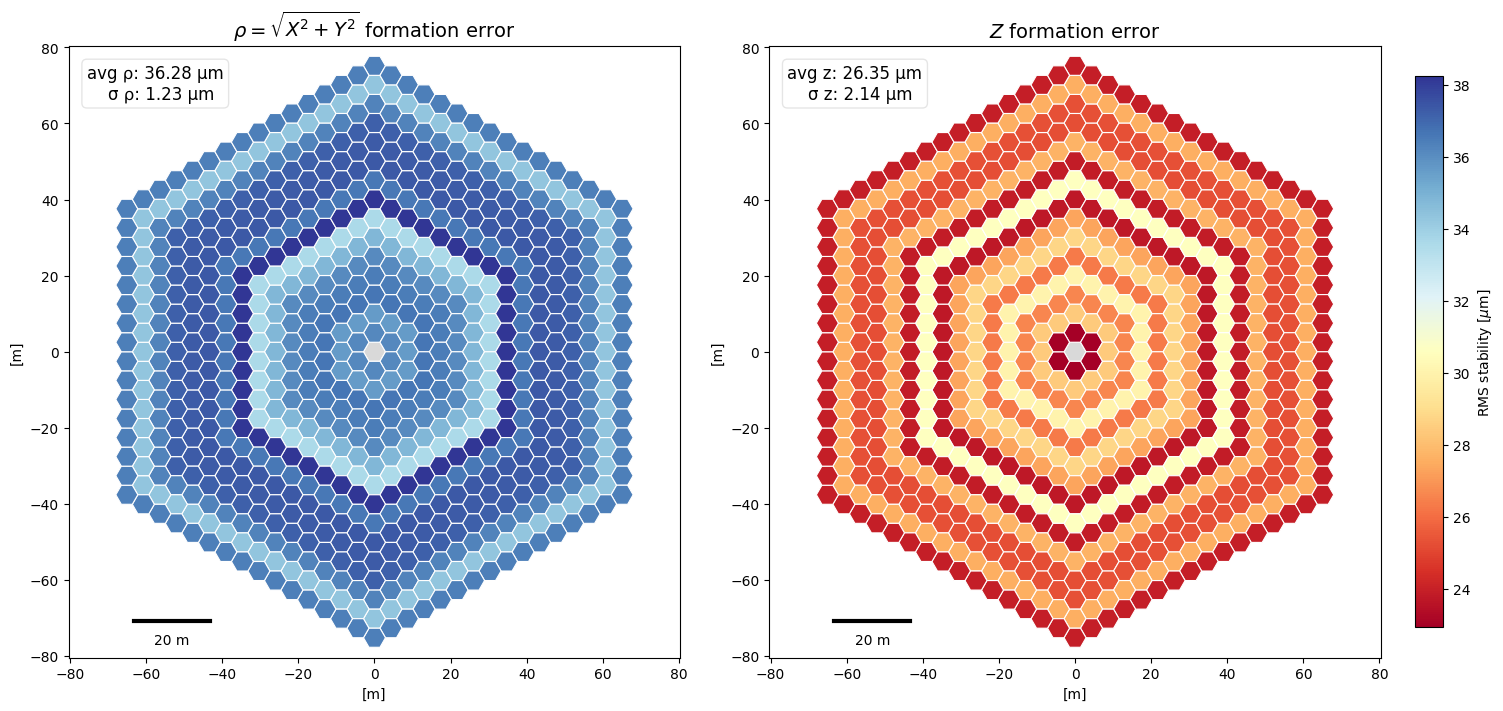

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon


def plot_two_hex_maps(
    rings_to_centers,
    data_left,
    data_right,
    ring_key=None,
    ftf=5.0,
    orientation=np.pi / 6,
    cmap_name="RdYlBu",
    titles=("Left", "Right"),
    save_path=None,
):
    """
    Plot two hex-aperture maps side by side.

    Parameters
    ----------
    rings_to_centers : dict[int, list[tuple[float, float]]]
        Dictionary like {1: [(x,y), ...], ..., 10: [(x,y), ...]}.
        The largest ring entry should contain the full aperture geometry.

    data_left, data_right : dict[int, float]
        Ring-indexed values for coloring, e.g. {0: 0.1, 1: 0.2, ..., 10: 1.0}.

    ring_key : int or None
        Which geometry to use. If None, uses the largest available ring key.

    ftf : float
        Flat-to-flat size of each hexagon.

    orientation : float
        Hex rotation in radians. np.pi/6 = 30 degrees.

    cmap_name : str
        Matplotlib colormap name.

    titles : tuple[str, str]
        Titles for the two panels.

    save_path : str or None
        If given, save the figure to this path.
    """
    if ring_key is None:
        ring_key = max(rings_to_centers.keys())

    centers = np.asarray(rings_to_centers[ring_key], dtype=float)
    centers = centers - centers.mean(axis=0)

    # Convert center positions to axial coordinates to determine ring index
    hex_size = ftf / np.sqrt(3)  # circumradius
    x = centers[:, 0]
    y = centers[:, 1]

    q = (2.0 / 3.0) * (x / hex_size)
    r = (-1.0 / 3.0) * (x / hex_size) + (1.0 / np.sqrt(3.0)) * (y / hex_size)
    s = -q - r

    ring_index = np.rint(
        np.max(np.vstack([np.abs(q), np.abs(r), np.abs(s)]), axis=0)
    ).astype(int)

    values_left = np.array([data_left.get(ring, np.nan) for ring in ring_index], dtype=float)
    values_right = np.array([data_right.get(ring, np.nan) for ring in ring_index], dtype=float)

    # Shared color scale across both plots for fair comparison
    all_values = np.concatenate(
        [values_left[np.isfinite(values_left)], values_right[np.isfinite(values_right)]]
    )
    if all_values.size == 0:
        raise ValueError("No finite values found in the provided dictionaries.")

    vmin = np.min(all_values)
    vmax = np.max(all_values)
    if vmin == vmax:
        vmax = vmin + 1e-12

    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.get_cmap(cmap_name)

    fig, axes = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)

    for ax, values, title in zip(axes, [values_left, values_right], titles):
        for (cx, cy), val in zip(centers, values):
            facecolor = cmap(norm(val)) if np.isfinite(val) else (0.85, 0.85, 0.85, 1.0)

            hexagon = RegularPolygon(
                (cx, cy),
                numVertices=6,
                radius=hex_size,
                orientation=orientation,
                facecolor=facecolor,
                edgecolor="white",
                linewidth=0.8,
            )
            ax.add_patch(hexagon)

        pad = ftf * 1.05
        xmin = centers[:, 0].min() - pad
        xmax = centers[:, 0].max() + pad
        ymin = centers[:, 1].min() - pad
        ymax = centers[:, 1].max() + pad

        # Make limits square
        xmid = 0.5 * (xmin + xmax)
        ymid = 0.5 * (ymin + ymax)
        half_range = max(xmax - xmin, ymax - ymin) / 2

        ax.set_xlim(xmid - half_range, xmid + half_range)
        ax.set_ylim(ymid - half_range, ymid + half_range)

        # Enforce square axes
        ax.set_box_aspect(1)
        ax.set_aspect("equal")
        ax.set_title(title, fontsize=14)

        ax.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
        ax.set_xlabel("[m]")
        ax.set_ylabel("[m]")

        # Add scale bar in data units
        bar_len = 20
        x0 = xmin + 0.05 * (xmax - xmin)
        y0 = ymin + 0.06 * (ymax - ymin)

        ax.plot([x0, x0 + bar_len], [y0, y0], color="black", lw=3)
        ax.text(
            x0 + bar_len / 2,
            y0 - 0.02 * (ymax - ymin),
            f"{bar_len} m",
            ha="center",
            va="top",
            fontsize=10,
        )

    # --- START HERE: correct left/right annotations ---
    mean_rho = np.nanmean(values_left)
    mean_z = np.nanmean(values_right)
    sigma_rho = np.nanstd(values_left)
    sigma_z = np.nanstd(values_right)

    notes_left = (
        f"avg ⍴: {mean_rho:.2f} µm\n"
        f"    σ ⍴: {sigma_rho:.2f} µm"
    )

    notes_right = (
        f"avg z: {mean_z:.2f} µm\n"
        f"    σ z: {sigma_z:.2f} µm"
    )

    axes[0].text(
        0.03, 0.97, notes_left,
        transform=axes[0].transAxes,
        ha="left", va="top",
        fontsize=12, color="black",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.1, edgecolor="k"),
    )

    axes[1].text(
        0.03, 0.97, notes_right,
        transform=axes[1].transAxes,
        ha="left", va="top",
        fontsize=12, color="black",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.1, edgecolor="k"),
    )
    # --- END HERE ---

    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        fraction=0.05,
        pad=0.02,
        shrink=0.9,
    )
    cbar.set_label(r"RMS stability [$\mu$m]")

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes


# -------------------------------------------------------------------------
# DATA
# -------------------------------------------------------------------------
lateral_rms = rms_rho_table[5000.0].to_dict()
lateral_rms = {int(k): v for k, v in lateral_rms.items()}
lateral_rms[0] = np.nan

z_rms = rms_z_table[5000.0].to_dict()
z_rms = {int(k): v for k, v in z_rms.items()}
z_rms[0] = np.nan

fig, axes = plot_two_hex_maps(
    rings_to_centers,
    lateral_rms,
    z_rms,
    titles=(r"$\rho = \sqrt{X^2 + Y^2}$ formation error", r"$Z$ formation error"),
    save_path="../analysis_scripts/rings_figs/hex_pair.png",
)

# IMSHOWS OF THE DET ON THE PLANE

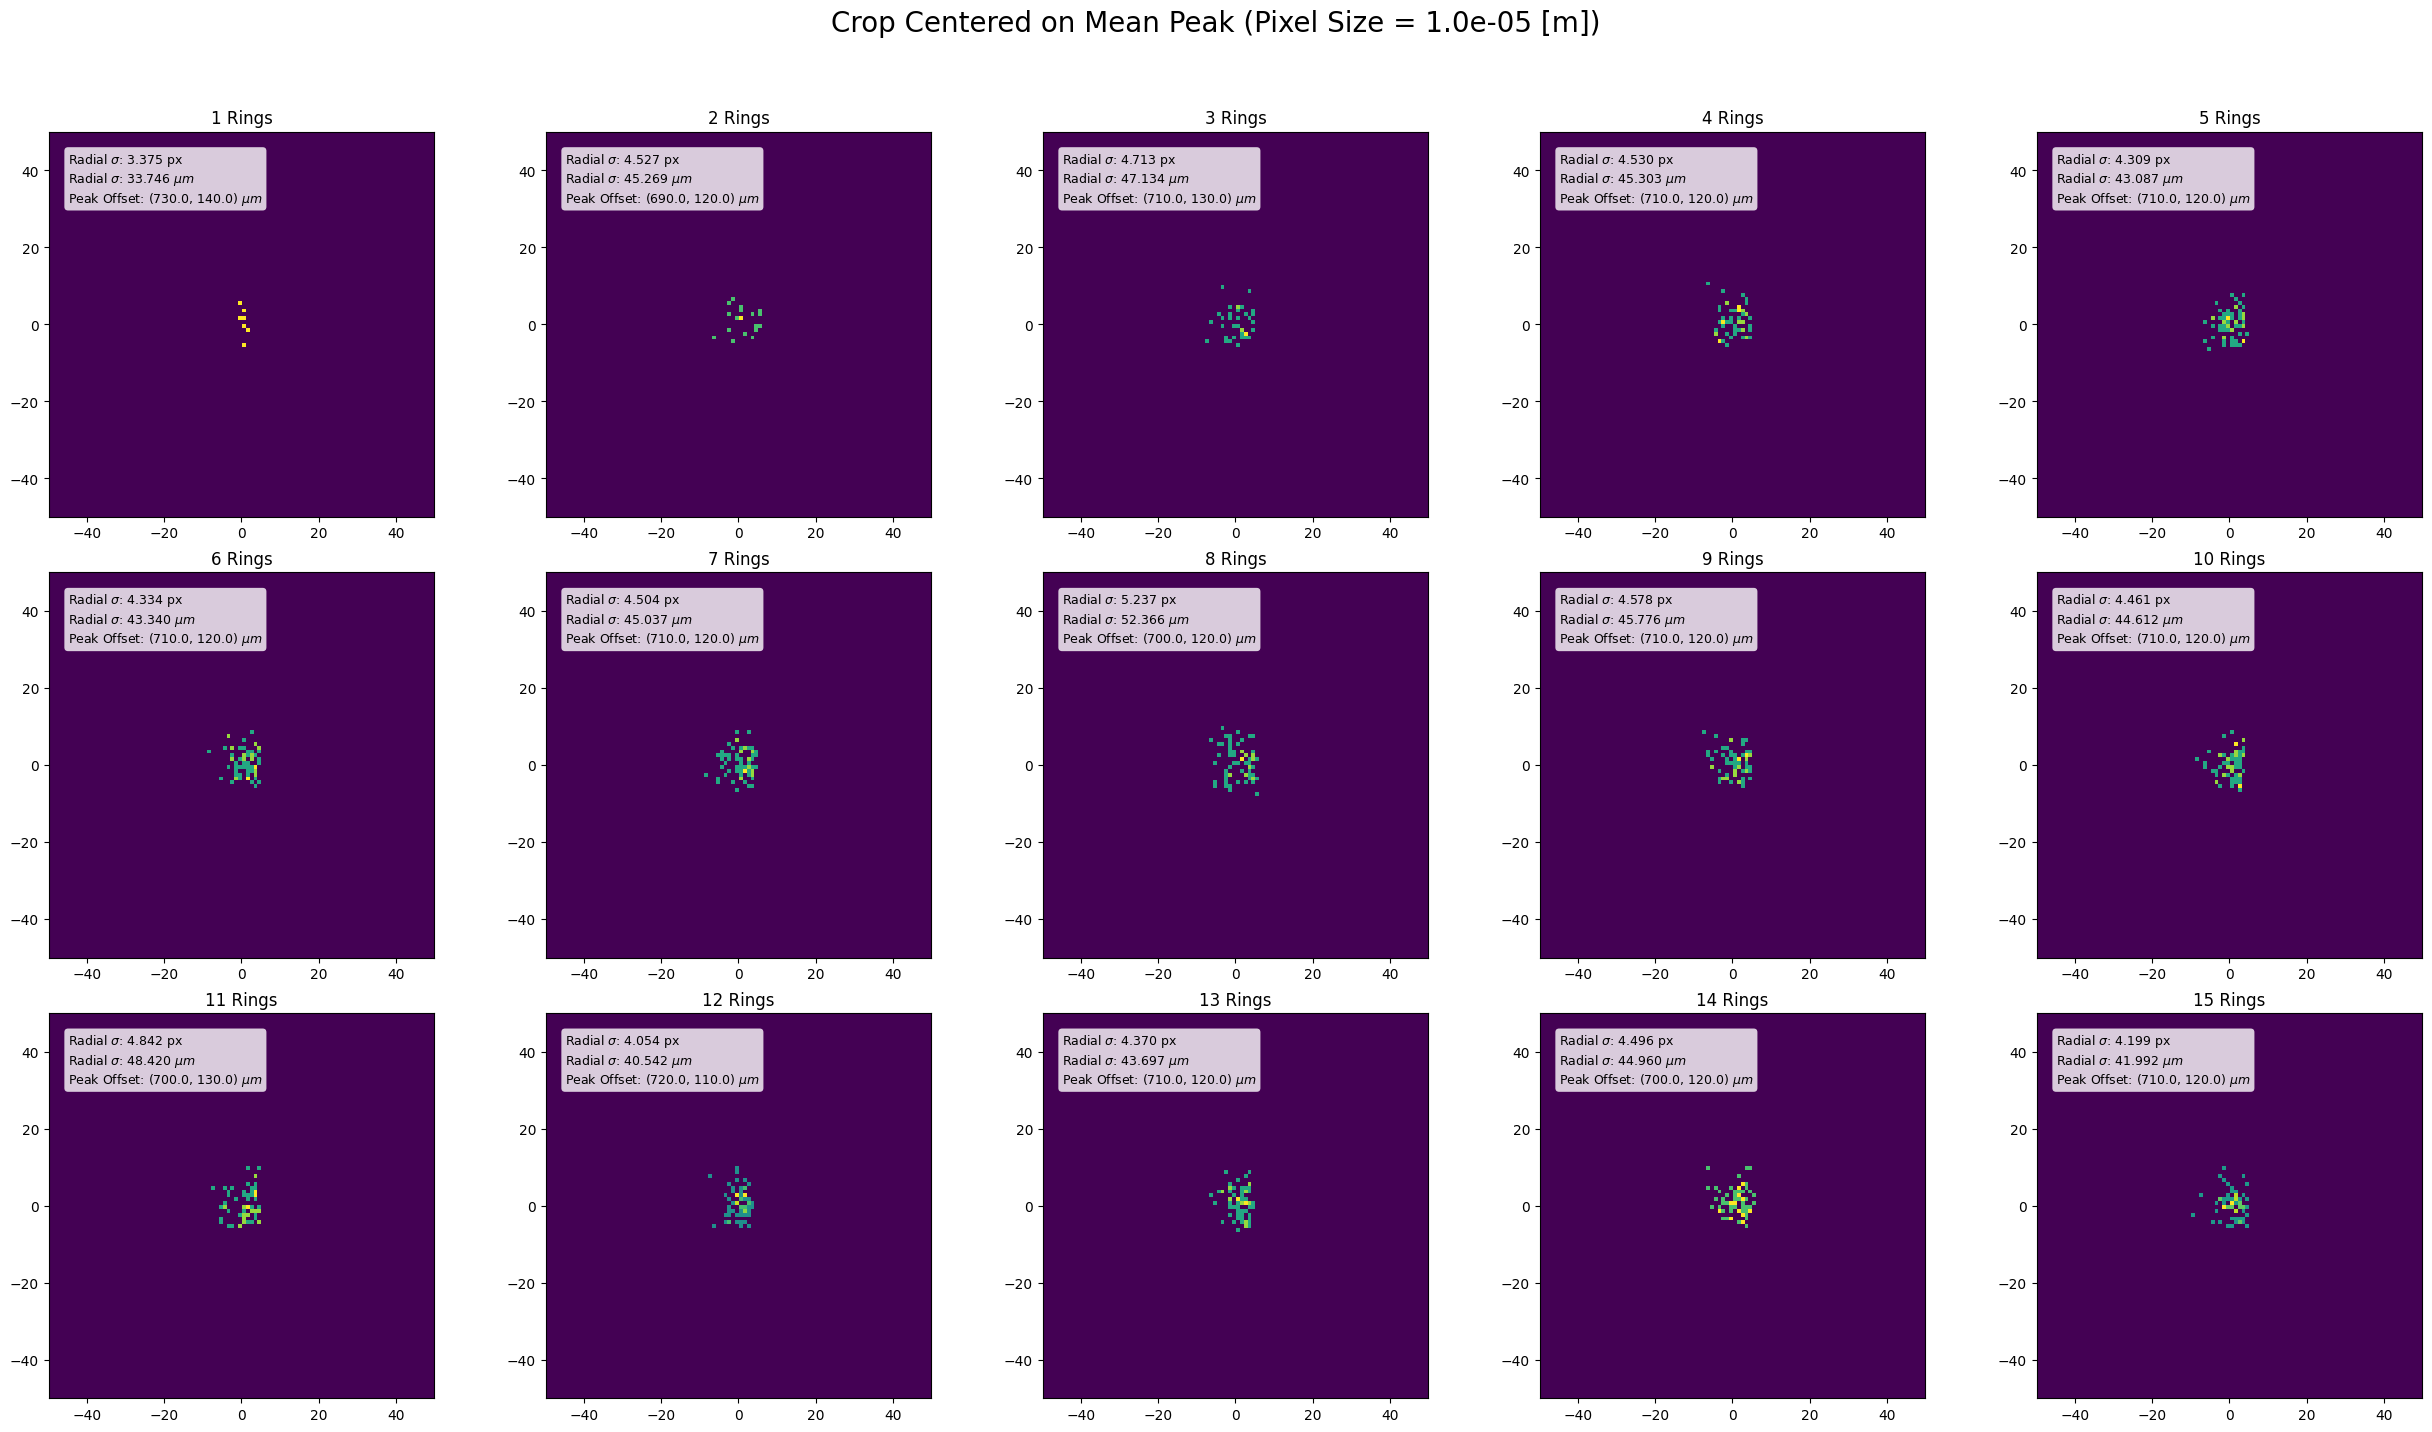

In [12]:
######## TAKE ONLY FINE TIME ARRAY
dt= 0.01
obs = 300
obs_ticks = obs*dt

# 1. Initialize the new list structure as a copy or empty list
# We create a list of lists to match the 'all_point_on_det_plane' structure
shorter_all_point_on_det_plane = []

####################################################################################################

for rings_idx, segments in enumerate(all_point_on_det_plane):
    ring_segments = []
    
    # 2. Iterate through each segment in the current ring
    for seg_idx in range(len(segments)):
        # Extract the last 'obs_ticks' from the (N, 2) array
        # Note: Ensure obs_ticks is an integer
        sliced_data = all_point_on_det_plane[rings_idx][seg_idx][-int(obs_ticks):, :]
        ring_segments.append(sliced_data)
    shorter_all_point_on_det_plane.append(ring_segments)

def compute_sigma_r(img, pixel_size):
    """
    Compute intensity-weighted radial standard deviation (σ_r).

    Parameters
    ----------
    img : 2D array
        Pixel intensity / occupancy map.
    pixel_size : float
        Physical size per pixel (used for unit conversion if needed, 
        though this version returns σ in pixel units).

    Returns
    -------
    sigma_r : float (in pixels)
    """
    img = np.asarray(img, dtype=float)

    total = np.sum(img)
    if total == 0:
        return 0.0

    # Get coordinate grids for the image
    ny, nx = img.shape
    y, x = np.indices((ny, nx))

    # 1. Find the weighted Centroid (Mean Position)
    x_mean = np.sum(x * img) / total
    y_mean = np.sum(y * img) / total

    # 2. Calculate Radial Variance
    # r^2 = (x - x_mean)^2 + (y - y_mean)^2
    r2 = (x - x_mean)**2 + (y - y_mean)**2
    var_r = np.sum(img * r2) / total

    # 3. Sigma is the square root of variance
    sigma_r = np.sqrt(var_r)

    return sigma_r

def bin_detector_hits(det_on_plane_m, pixel_size, crop_half_width=300, n_pix=2048):
    """
    Bins hits and returns a crop centered on the mean peak position of the data.
    """
    det_on_plane_m = np.asarray(det_on_plane_m, dtype=float)
    if det_on_plane_m.size == 0:
        return np.zeros((crop_half_width*2, crop_half_width*2)), 0, 0

    # 1. Standard Binning Logic
    half_detector_m = (n_pix / 2) * pixel_size
    x = det_on_plane_m[:, 0] + half_detector_m
    y = det_on_plane_m[:, 1] + half_detector_m

    ix = np.floor(x / pixel_size).astype(int)
    iy = np.floor(y / pixel_size).astype(int)

    valid = (ix >= 0) & (ix < n_pix) & (iy >= 0) & (iy < n_pix)
    ix, iy = ix[valid], iy[valid]

    if len(ix) == 0:
        return np.zeros((crop_half_width*2, crop_half_width*2)), 0, 0

    # 2. Find the Mean Peak Position (Centroid) in Pixel Space
    # This finds the average pixel index of all hits
    mean_ix = int(np.round(np.mean(ix)))
    mean_iy = int(np.round(np.mean(iy)))

    # 3. Create the full map and populate it
    img_full = np.zeros((n_pix, n_pix), dtype=np.int32)
    np.add.at(img_full, (iy, ix), 1)

    # 4. Define Crop Boundaries centered at the Mean Position
    y0, y1 = max(mean_iy - crop_half_width, 0), min(mean_iy + crop_half_width, n_pix)
    x0, x1 = max(mean_ix - crop_half_width, 0), min(mean_ix + crop_half_width, n_pix)

    img_crop = img_full[y0:y1, x0:x1]
    
    # Return the image and the pixel-offset for plotting labels
    return img_crop, mean_ix, mean_iy

# ... compute_sigma_r stays the same ...

###########################
# CONFIGURATION & PLOTTING
###########################

order = -6
pixel_size = 10 * (10**order)
crop = 50 
rows, cols = 3, 5

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(cols*5, rows*5))
plt.suptitle(f'Crop Centered on Mean Peak (Pixel Size = {pixel_size:.1e} [m])', fontsize=20)
axes = axes.flatten()

for rings_idx, segments in enumerate(shorter_all_point_on_det_plane):
    if rings_idx >= len(axes): break
        
    # Combine all segments for this ring to find the global peak for this subplot
    all_segments_data = np.concatenate(segments, axis=0)
    
    # Get crop centered on the peak
    ring_image, center_x, center_y = bin_detector_hits(
        all_segments_data, pixel_size=pixel_size, crop_half_width=crop
    )
    
    ax = axes[rings_idx]
    
    # Update extent to show coordinates relative to the peak center (0 is the peak)
    h, w = ring_image.shape
    im = ax.imshow(ring_image + 1, origin='lower', norm=LogNorm(),
                   extent=[-w//2, w//2, -h//2, h//2], cmap='viridis')
    
    ax.set_title(f'{rings_idx+1} Rings')
    
    # Statistics
    sig_px = compute_sigma_r(ring_image, pixel_size)
    sig_um = sig_px * pixel_size * 1e6
    
    # Calculate physical offset from detector center (0,0) in microns
    offset_x_um = (center_x - (2048/2)) * pixel_size * 1e6
    offset_y_um = (center_y - (2048/2)) * pixel_size * 1e6

    notes =  f'Radial $\sigma$: {sig_px:.3f} px\n'
    notes += f'Radial $\sigma$: {sig_um:.3f} $\mu m$\n'
    notes += f'Peak Offset: ({offset_x_um:.1f}, {offset_y_um:.1f}) $\mu m$'
    
    ax.text(0.05, 0.95, notes, transform=ax.transAxes, ha='left', va='top',
            fontsize=9, bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(f'../analysis_scripts/rings_figs/det_on_plane.png')

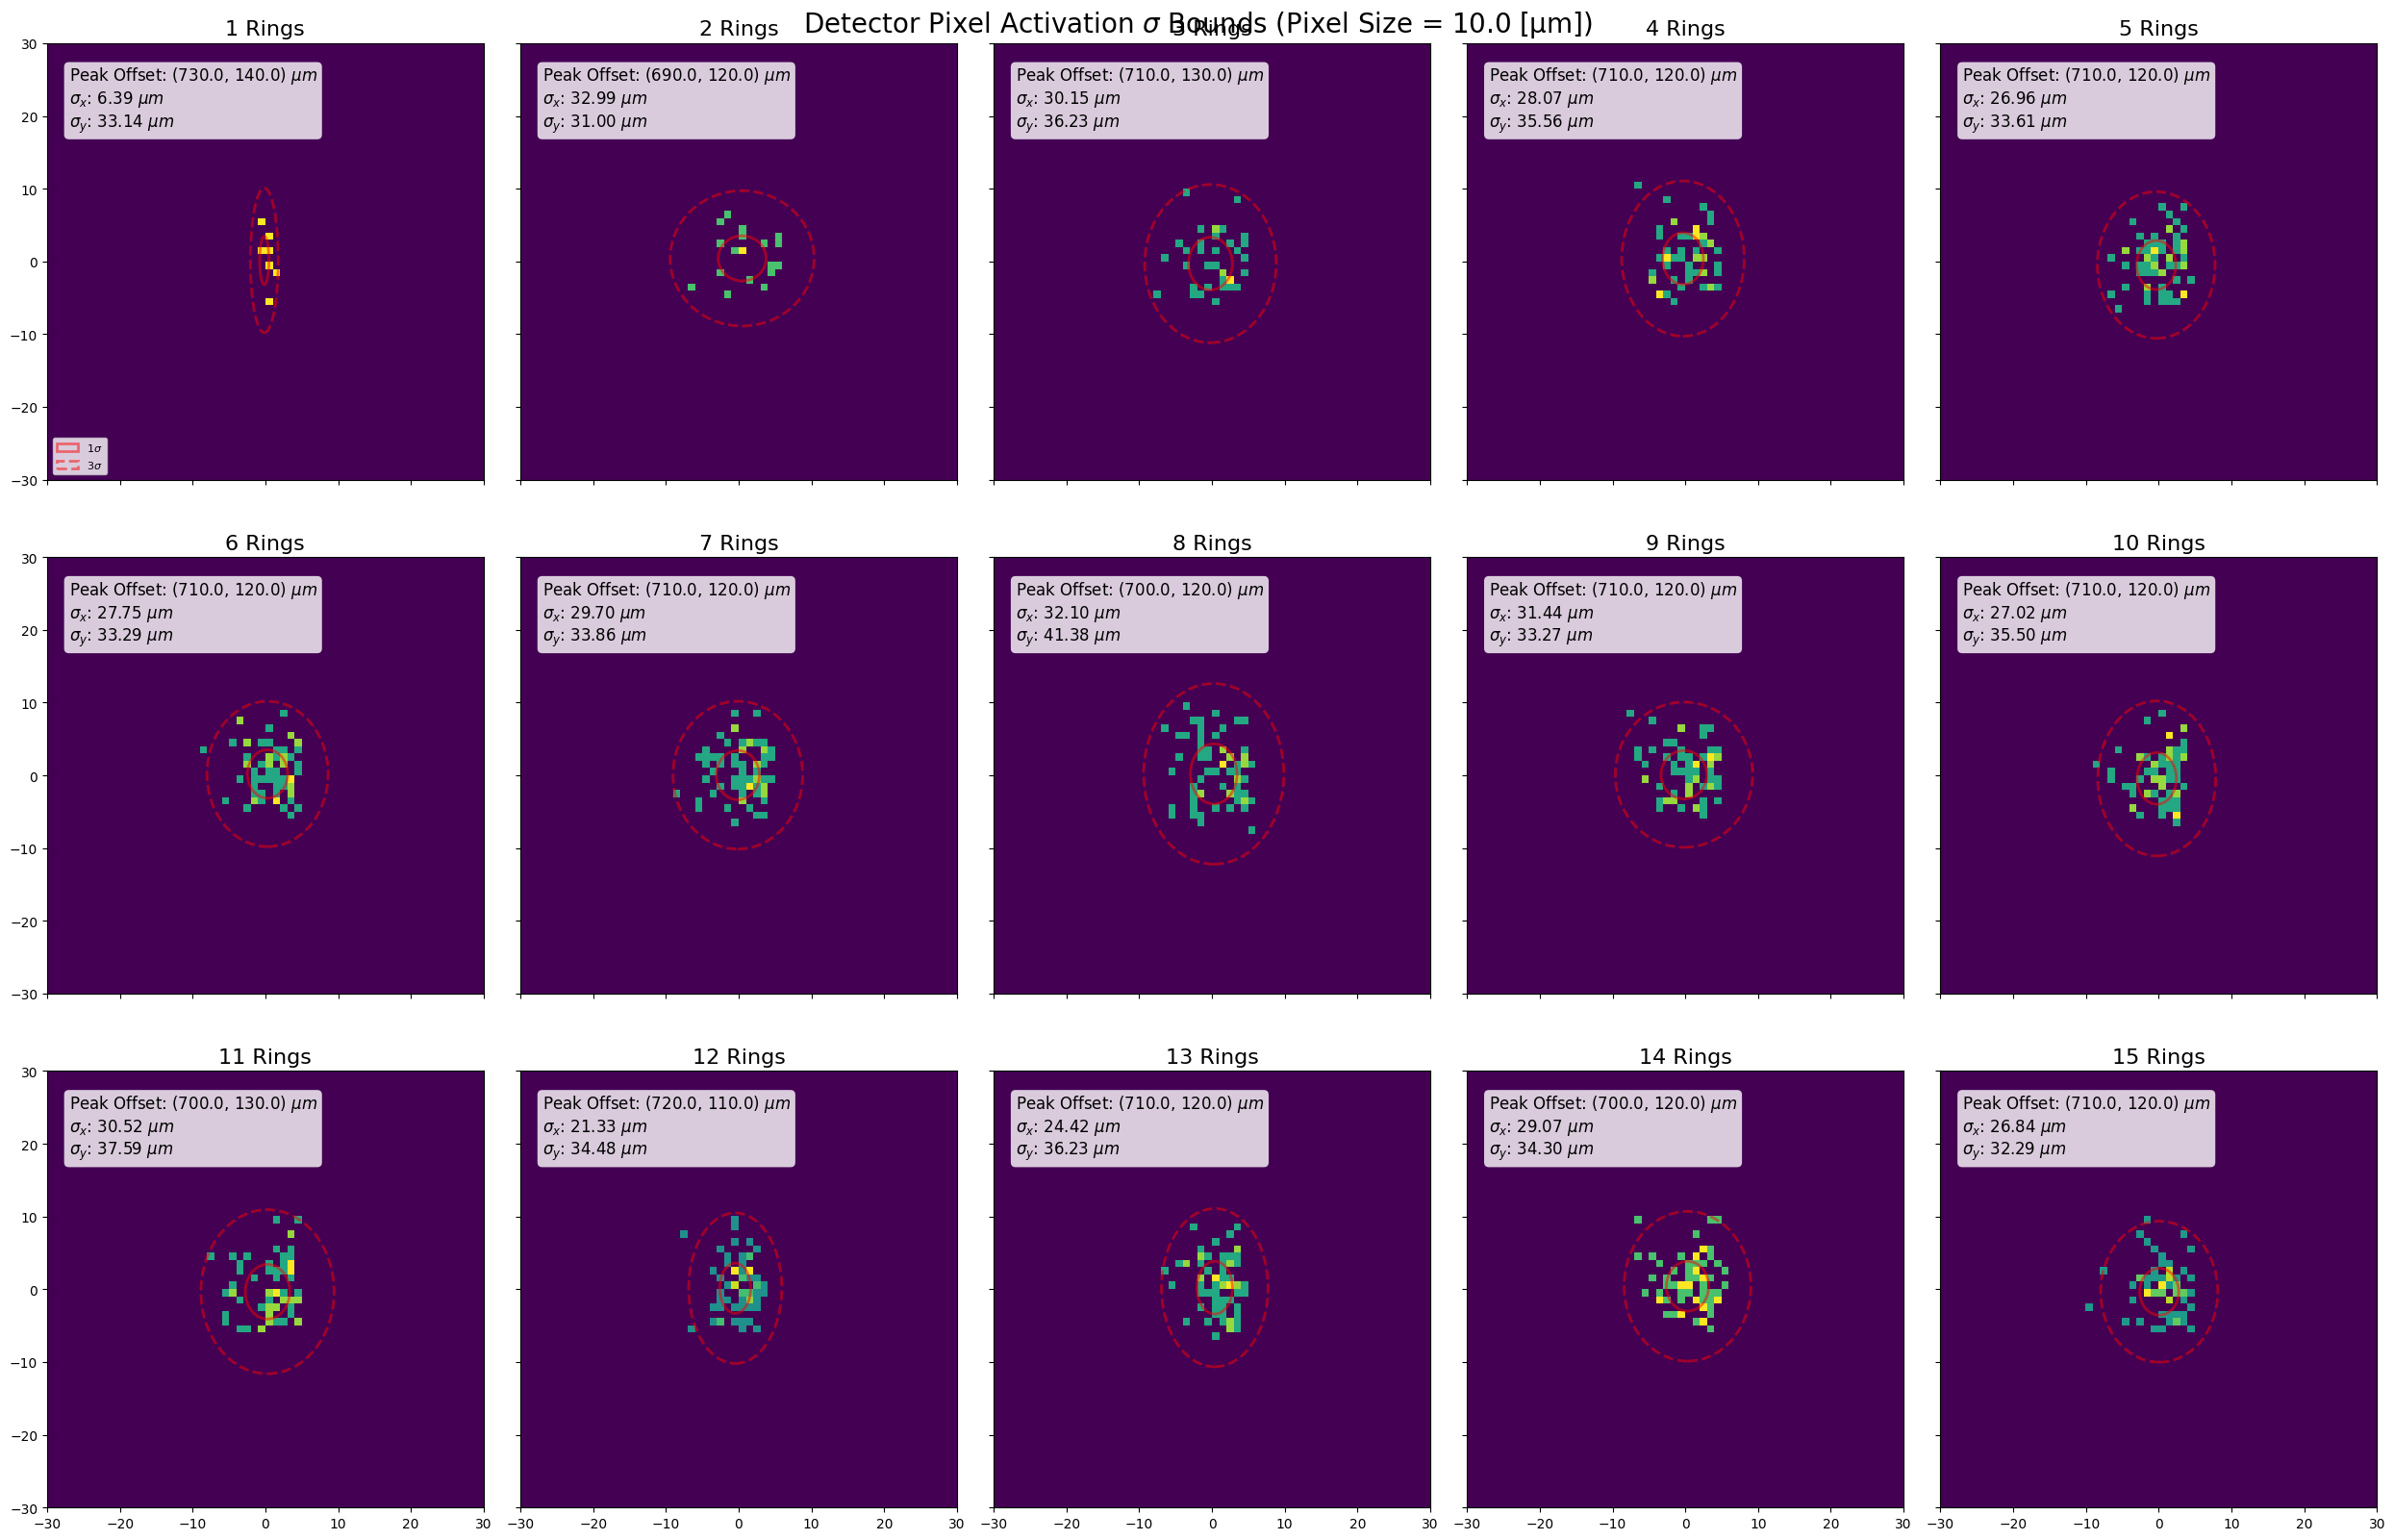

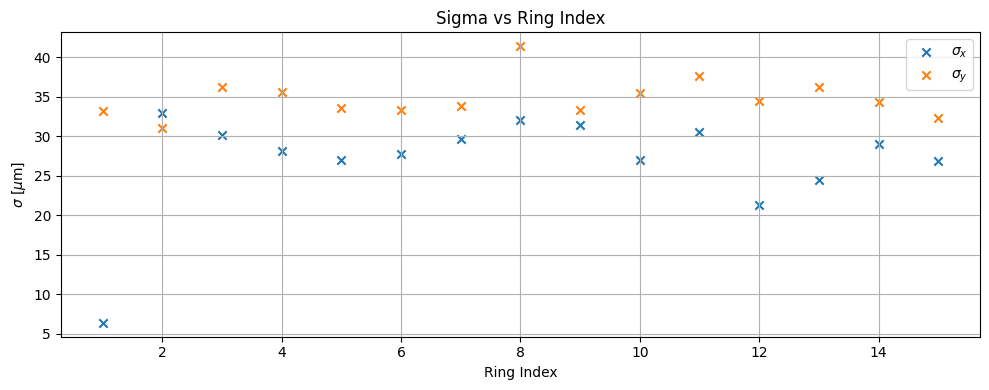

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
from tqdm import tqdm

def compute_stats(img):
    """
    Compute centroid and separate x, y standard deviations.
    """
    img = np.asarray(img, dtype=float)
    total = np.sum(img)
    if total == 0:
        return None

    ny, nx = img.shape
    y, x = np.indices((ny, nx))

    # Centroid
    x_mean = np.sum(x * img) / total
    y_mean = np.sum(y * img) / total

    # Separate variances
    var_x = np.sum(img * (x - x_mean)**2) / total
    var_y = np.sum(img * (y - y_mean)**2) / total

    return {
        'x_mean': x_mean,
        'y_mean': y_mean,
        'sigma_x': np.sqrt(var_x),
        'sigma_y': np.sqrt(var_y)
    }

# ... [Keep your bin_detector_hits and shorter_all_point_on_det_plane logic as is] ...

###########################
# CONFIGURATION & PLOTTING
###########################

order = -6
pixel_size = 10 * (10**order)
crop = 30
rows, cols = 3, 5

# Storage for sigma scatter plot
sigma_x_list = []
sigma_y_list = []
ring_indices = []

fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(25, 17), sharex=True, sharey=True)
plt.suptitle(f'Detector Pixel Activation $\\sigma$ Bounds (Pixel Size = {(pixel_size*1e6)} [µm])', fontsize=20)
axes = axes.flatten()

for rings_idx, segments in enumerate(shorter_all_point_on_det_plane):
    if rings_idx >= len(axes):
        break

    all_segments_data = np.concatenate(segments, axis=0)

    # Get crop centered on the peak
    ring_image, center_ix, center_iy = bin_detector_hits(
        all_segments_data, pixel_size=pixel_size, crop_half_width=crop
    )

    ax = axes[rings_idx]
    h, w = ring_image.shape

    # Show the heatmap
    # Note: Extent is centered at (0,0) because bin_detector_hits centers on peak
    im = ax.imshow(
        ring_image + 1,
        origin='lower',
        norm=LogNorm(),
        extent=[-w//2, w//2, -h//2, h//2],
        cmap='viridis'
    )

    # Compute Statistics for Ellipses
    stats = compute_stats(ring_image)

    if stats:
        # Store sigma values for separate scatter plot
        sigma_x_list.append(stats['sigma_x'] * pixel_size * 1e6)  # um
        sigma_y_list.append(stats['sigma_y'] * pixel_size * 1e6)  # um
        ring_indices.append(rings_idx + 1)

        # Coordinates relative to the center of the crop
        cx_rel = stats['x_mean'] - (w / 2)
        cy_rel = stats['y_mean'] - (h / 2)

        # Plot 1-sigma and 3-sigma ellipses
        for n_sig, color, style in zip([1, 3], ['red', 'red'], ['-', '--']):
            ell = Ellipse(
                xy=(cx_rel, cy_rel),
                width=2 * n_sig * stats['sigma_x'],
                height=2 * n_sig * stats['sigma_y'],
                edgecolor=color,
                facecolor='none',
                linestyle=style,
                alpha=0.5,
                linewidth=2,
                label=f'{n_sig}$\\sigma$'
            )
            ax.add_patch(ell)

        # Build Notes
        sig_x_um = stats['sigma_x'] * pixel_size * 1e6
        sig_y_um = stats['sigma_y'] * pixel_size * 1e6
        offset_x_um = (center_ix - (2048/2)) * pixel_size * 1e6
        offset_y_um = (center_iy - (2048/2)) * pixel_size * 1e6

        notes = (f'Peak Offset: ({offset_x_um:.1f}, {offset_y_um:.1f}) $\\mu m$\n'
                 f'$\\sigma_x$: {sig_x_um:.2f} $\\mu m$\n'
                 f'$\\sigma_y$: {sig_y_um:.2f} $\\mu m$')

        ax.text(
            0.05, 0.95, notes,
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=12,
            color='black',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='none')
        )

    ax.set_title(f'{rings_idx+1} Rings', fontsize=16)

# Add a legend to the first axis
axes[0].legend(loc='lower left', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 1.02])
plt.savefig('../analysis_scripts/rings_figs/det_on_plane_ellipses.png')
plt.show()

# -----------------------------
# Sigma vs ring index scatter plot
# -----------------------------
plt.figure(figsize=(10, 4))

plt.scatter(ring_indices, sigma_x_list, label=r'$\sigma_x$', marker='x')
plt.scatter(ring_indices, sigma_y_list, label=r'$\sigma_y$', marker='x')

plt.xlabel('Ring Index')
plt.ylabel(r'$\sigma$ [$\mu$m]')
plt.title('Sigma vs Ring Index')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('../analysis_scripts/rings_figs/sigma_vs_rings.png')
plt.show()

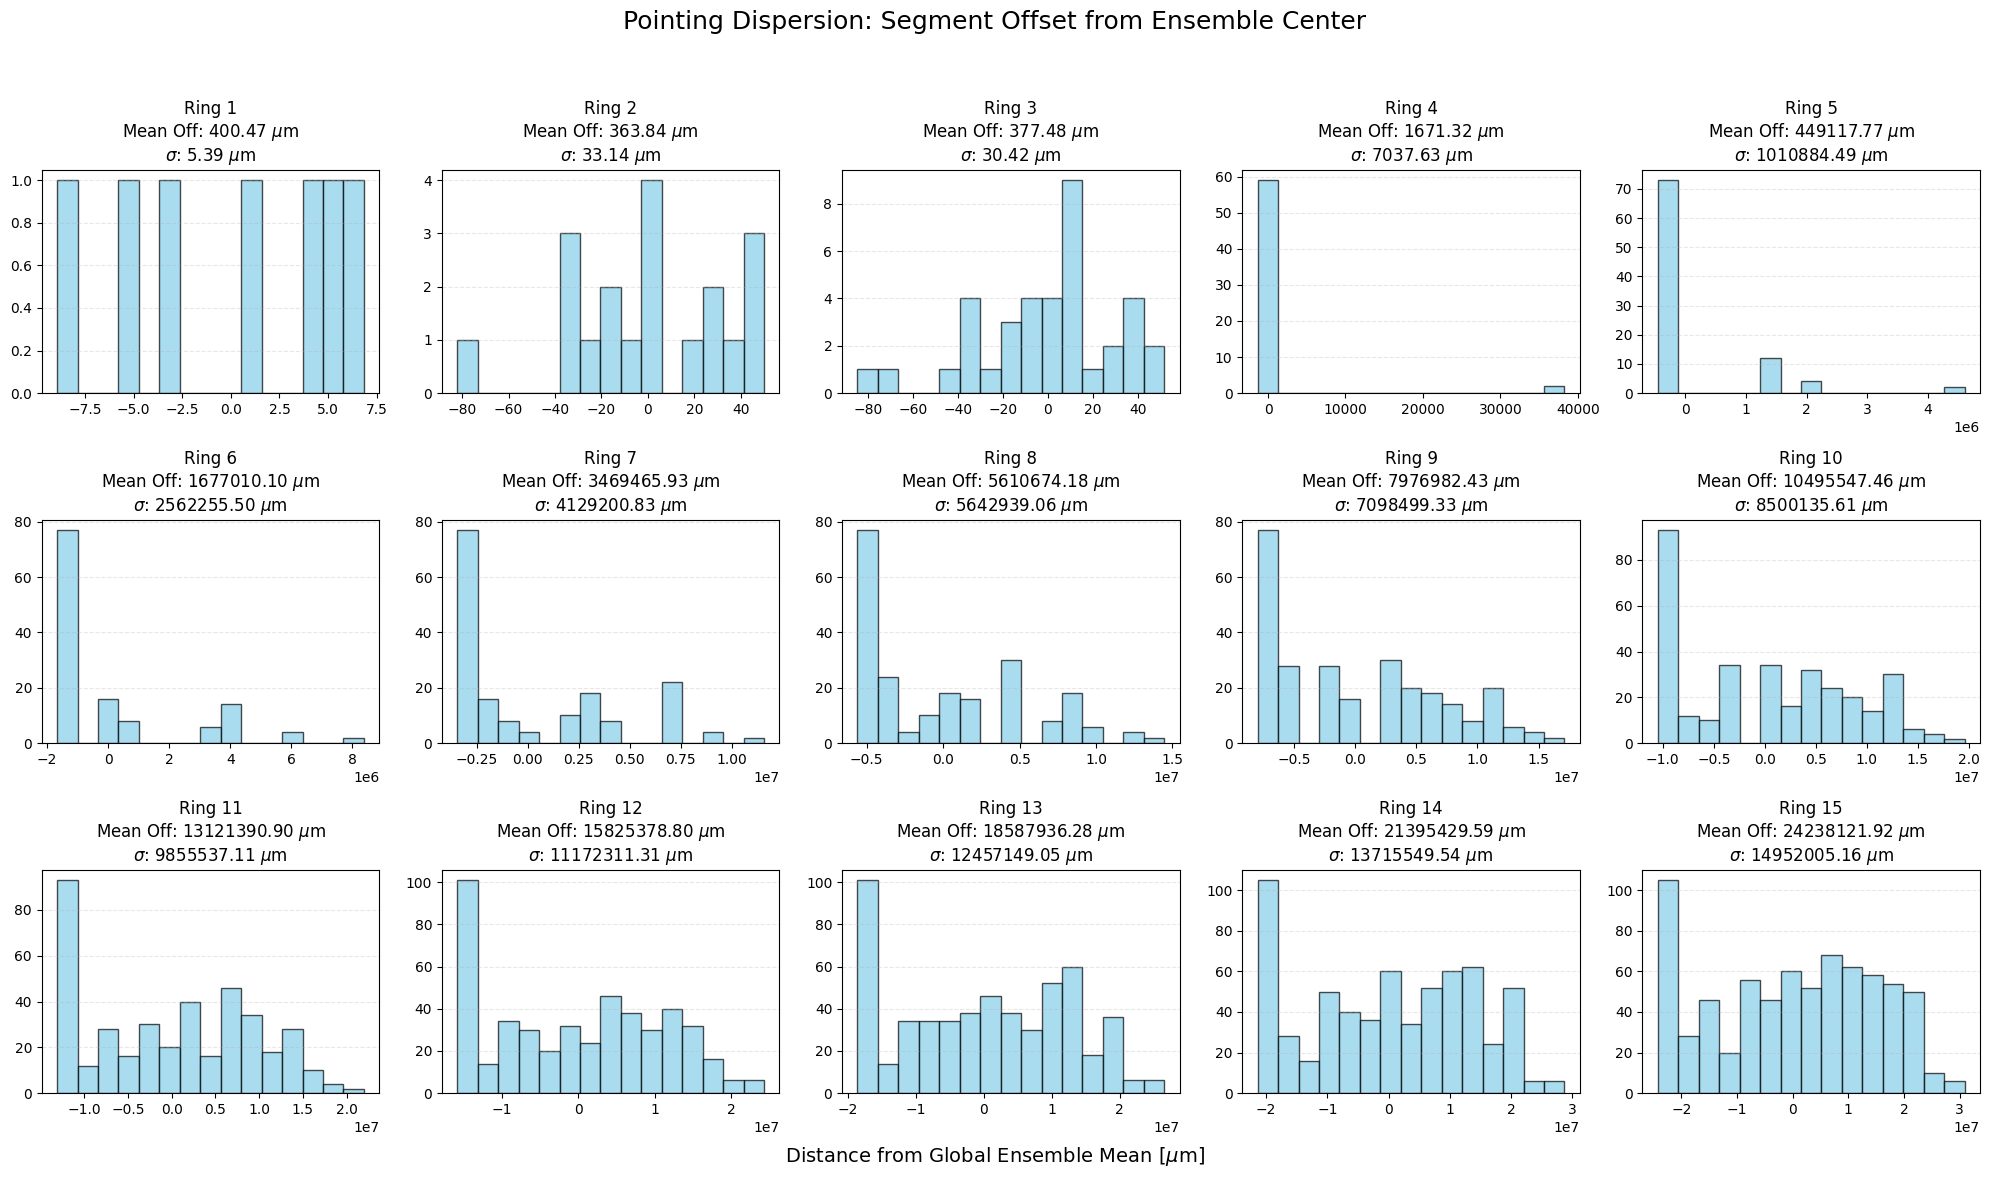

In [14]:
###############################################################################
# 2. JITTER ANALYSIS FUNCTIONS
################################################################################

def plot_pointing_dispersion(all_segments_data, obs_ticks=100):
    """
    Measures how 'scattered' the segments are relative to each other.
    Calculates distance of each segment's mean from the global ensemble mean.
    """
    # 1. Calculate the 'Ensemble Mean' (The Pointing Center)
    # We find the average (x,y) of every single segment's mean position
    segment_means = []
    
    for ring in all_segments_data:
        for seg in ring:
            sliced = seg[-int(obs_ticks):, :]
            # Mean position of this specific segment
            s_x = np.mean(sliced[:, 0])
            s_y = np.mean(sliced[:, 1])
            segment_means.append([s_x, s_y])
            
    segment_means = np.array(segment_means)
    ensemble_mean_x = np.mean(segment_means[:, 0])
    ensemble_mean_y = np.mean(segment_means[:, 1])

    # 2. Setup Plotting Grid
    n_rings = len(all_segments_data)
    cols = 5
    rows = (n_rings + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
    axes = axes.flatten()
    plt.suptitle('Pointing Dispersion: Segment Offset from Ensemble Center', fontsize=18)

    # 3. Calculate and Plot Error per Ring
    for r_idx, ring in enumerate(all_segments_data):
        offsets_um = []
        for seg in ring:
            sliced = seg[-int(obs_ticks):, :]
            s_x = np.mean(sliced[:, 0])
            s_y = np.mean(sliced[:, 1])
            
            # Distance from the average of all segments
            dist = np.sqrt((s_x - ensemble_mean_x)**2 + (s_y - ensemble_mean_y)**2)
            offsets_um.append(dist * 1e6) # Convert to microns

        # Stats for the title
        r_mean = np.mean(offsets_um)
        r_std = np.std(offsets_um)
        ax = axes[r_idx]
        ax.hist(offsets_um-r_mean, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
        
        ax.set_title(f"Ring {r_idx+1}\nMean Off: {r_mean:.2f} $\mu$m\n$\sigma$: {r_std:.2f} $\mu$m")
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Cleanup empty slots
    for j in range(r_idx + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.text(0.5, 0.02, 'Distance from Global Ensemble Mean [$\mu$m]', ha='center', fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

shorter_all_point_on_det_plane = []
for rings_idx, segments in enumerate(all_point_on_det_plane):
    ring_segments = []
    
    # 2. Iterate through each segment in the current ring
    for seg_idx in range(len(segments)):
        # Extract the last 'obs_ticks' from the (N, 2) array
        # Note: Ensure obs_ticks is an integer
        sliced_data = all_point_on_det_plane[rings_idx][seg_idx][-int(obs_ticks):, :]
        ring_segments.append(sliced_data)
        
    shorter_all_point_on_det_plane.append(ring_segments)

# Run the analysis
plot_pointing_dispersion(shorter_all_point_on_det_plane, obs_ticks=obs_ticks)
